# Correlation Plots On Our embeddings

In [1]:
import torch

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import scipy.sparse as sp
import gendata.io as io
from matplotlib.patches import Patch

! not connected, call: ln.connect('account/name')


In [3]:

# List of all embeddings to compare
EMBEDDINGS = [
    "AIDOdna_(D=4352)",
    "AIDOprot_mean_(D=384)",
    "AIDOprot_seq+struct_(D=1024)",
    "ESM2_(D=1280)",
    "RAG-16B_Human_Protein_Embedding_with_structure_mean_pooled_(D=2304)",
    "RAG-16B_Human_Protein_Embedding_without_structure_mean_pooled_(D=2304)",
    "STRING_sequence_(D=1024)",
    "TranscriptFormer_essential_CELL_LINE_controls_(D=2048)",
    "Geneformer_essential_CELL_LINE_controls_(D=512)",
    "AIDO.Cell_3M_positional_(D=128)",
    # "AIDO.Cell_10M_positional_(D=256)",
    # "AIDO.Cell_100M_positional_(D=640)",
    "AIDOcell_3M_essential_CELL_LINE_2025_11_26_(D=128)",
    "AIDOcell_10M_essential_CELL_LINE_2025_11_26_(D=256)",
    "AIDOcell_100M_essential_CELL_LINE_2025_11_26_(D=640)",
    "scGPT_essential_CELL_LINE_controls_(D=512)",
    "scPRINT_essential_CELL_LINE_controls_(D=512)",
    "scGenePT_GO_BP_(D=1536)",
    "scGenePT_GO_CC_(D=1536)",
    "scGenePT_GO_MF_(D=1536)",
    "scGenePT_GO_all_(D=1536)",
    "scGenePT_NCBI+UniProt_(D=1536)",
    "scGenePT_NCBI_(D=1536)",
    "DepMap_Gene_Effect_(D=318)",
    "GenotypeVAE_(D=256)",
    "KG_WaveGC_G_StringDB_combined_0.0_(D=128)",
    "GNN_Simple_Official_(D=256)",
    "STRING_Spectral_Medium_Conf_(D=128)",
    "STRING_network_(D=512)"
]

CELL_LINE = "K-562"

Helper Functions

In [4]:


def load_all_embeddings():
    """Load all embeddings and return dict mapping name -> AnnData."""
    repo = io.EmbeddingRepository("Gene", io.EMBEDDING_URI, "ensembl_gene_id")
    embeddings = {}

    for emb_name in EMBEDDINGS:
        actual_name = emb_name.replace("CELL_LINE", CELL_LINE)
        try:
            if "Geneformer" in actual_name:
                emb = repo.get_embedding(actual_name)
            else:
                emb = repo.get_embedding(actual_name)
            embeddings[emb_name] = emb
            print(f"Loaded {actual_name}: {emb.n_obs} genes")
        except Exception as e:
            print(f"Failed to load {actual_name}: {e}")

    return embeddings


def find_common_genes(embeddings):
    """Find genes common to all embeddings and report top 5 loss contributors."""
    gene_sets = {name: set(emb.obs_names) for name, emb in embeddings.items()}

    # Start with all genes from first embedding
    common_genes = gene_sets[list(gene_sets.keys())[0]].copy()
    for genes in gene_sets.values():
        common_genes &= genes

    # Find top 5 embeddings causing largest gene loss
    gene_counts = [(name, len(genes)) for name, genes in gene_sets.items()]
    gene_counts.sort(key=lambda x: x[1])
    print(f"\nTop 5 embeddings with fewest genes (largest loss):")
    for name, count in gene_counts[:5]:
        print(f"  {name}: {count} genes")

    print(f"\nTotal common genes: {len(common_genes)}")
    return sorted(common_genes)


def align_embeddings(embeddings, common_genes):
    """Align all embeddings to common gene set."""
    aligned = {}
    for name, emb in embeddings.items():
        emb_subset = emb[emb.obs_names.isin(common_genes)].copy()
        # Reorder to match common_genes order
        emb_subset = emb_subset[common_genes, :]
        aligned[name] = emb_subset.X
    return aligned


def apply_pca(embeddings_dict, n_components=10):
    """Apply PCA to reduce dimensionality of embeddings."""
    pca_embeddings = {}
    for name, X in embeddings_dict.items():
        # Convert sparse matrix to dense if needed
        if sp.issparse(X):
            X = X.toarray()
        X_scaled = StandardScaler().fit_transform(X)
        n_comp = min(n_components, X.shape[0], X.shape[1])
        pca = PCA(n_components=n_comp)
        pca_embeddings[name] = pca.fit_transform(X_scaled)
    return pca_embeddings


def compute_cca_score(emb1, emb2):
    """Compute CCA similarity score between two embeddings."""
    n_components = min(emb1.shape[1], emb2.shape[1])
    cca = CCA(n_components=n_components)
    cca.fit(emb1, emb2)
    return cca.score(emb1, emb2)


def compute_similarity_matrix(embeddings_dict):
    """Compute pairwise CCA similarity matrix."""
    names = sorted(embeddings_dict.keys())
    n = len(names)
    sim_matrix = np.zeros((n, n))

    for i, name_i in enumerate(names):
        for j, name_j in enumerate(names):
            if i <= j:
                score = compute_cca_score(embeddings_dict[name_i], embeddings_dict[name_j])
                sim_matrix[i, j] = score
                sim_matrix[j, i] = score
        print(f"Computed row {i+1}/{n}")

    return pd.DataFrame(sim_matrix, index=names, columns=names)


def create_short_names(names):
    """Create shorter display names for the heatmap."""
    short_names = []
    for name in names:
        # Remove dimension info and simplify
        short = name.split("_(D=")[0]
        short = short.replace("_essential_CELL_LINE_2025_11_26", "")
        short = short.replace("_essential_CELL_LINE_controls", "")
        short = short.replace("_Human_Protein_Embedding_", "_")
        short = short.replace("mean_pooled", "")
        short_names.append(short)
    return short_names


# Pulling the Embeddings and Preprocessing


The preprocessing aligns closesly to this: https://github.com/ylaboratory/gene-embedding-benchmarks/blob/master/src/other/cca.py


In [5]:
# 1. Load all embeddings
print("Loading embeddings...")
embeddings = load_all_embeddings()

# 2. Find common genes
print("\nFinding common genes...")
common_genes = find_common_genes(embeddings)

# 3. Align embeddings to common genes
print("\nAligning embeddings...")
aligned = align_embeddings(embeddings, common_genes)

# 4. Apply PCA for dimensionality reduction
print("\nApplying PCA...")
pca_embeddings = apply_pca(aligned, n_components=10)

# 5. Compute CCA similarity matrix
print("\nComputing CCA similarity matrix...")
sim_df = compute_similarity_matrix(pca_embeddings)

Loading embeddings...
Loaded AIDOdna_(D=4352): 18924 genes
Loaded AIDOprot_mean_(D=384): 19078 genes
Loaded AIDOprot_seq+struct_(D=1024): 21851 genes
Loaded ESM2_(D=1280): 23122 genes
Loaded RAG-16B_Human_Protein_Embedding_with_structure_mean_pooled_(D=2304): 18910 genes
Loaded RAG-16B_Human_Protein_Embedding_without_structure_mean_pooled_(D=2304): 18910 genes
Loaded STRING_sequence_(D=1024): 18753 genes
Loaded TranscriptFormer_essential_K-562_controls_(D=2048): 6537 genes
Loaded Geneformer_essential_K-562_controls_(D=512): 6537 genes
Loaded AIDO.Cell_3M_positional_(D=128): 19205 genes
Loaded AIDOcell_3M_essential_K-562_2025_11_26_(D=128): 19066 genes
Loaded AIDOcell_10M_essential_K-562_2025_11_26_(D=256): 19066 genes
Loaded AIDOcell_100M_essential_K-562_2025_11_26_(D=640): 19066 genes
Loaded scGPT_essential_K-562_controls_(D=512): 6562 genes
Loaded scPRINT_essential_K-562_controls_(D=512): 6537 genes
Loaded scGenePT_GO_BP_(D=1536): 17017 genes
Loaded scGenePT_GO_CC_(D=1536): 18029 gen

# Plotting

In [7]:
import matplotlib as mpl
import json

with open("/home/jovyan/pert-bench-fusion-paper/results/metadata/fig_index.json", "r") as f:
    fig_index = json.load(f)

mpl.rcParams.update(fig_index["mpl_params"])
mpl.rcParams.update({
    "axes.grid": False,
    "ytick.minor.visible": False,
    "xtick.minor.visible": False,
    "ytick.left": True,
})


Plotting heatmap...


/home/jovyan/perturbation_embedding_fusion/.venv/lib/python3.12/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)



Saved heatmap to fig_3.pdf


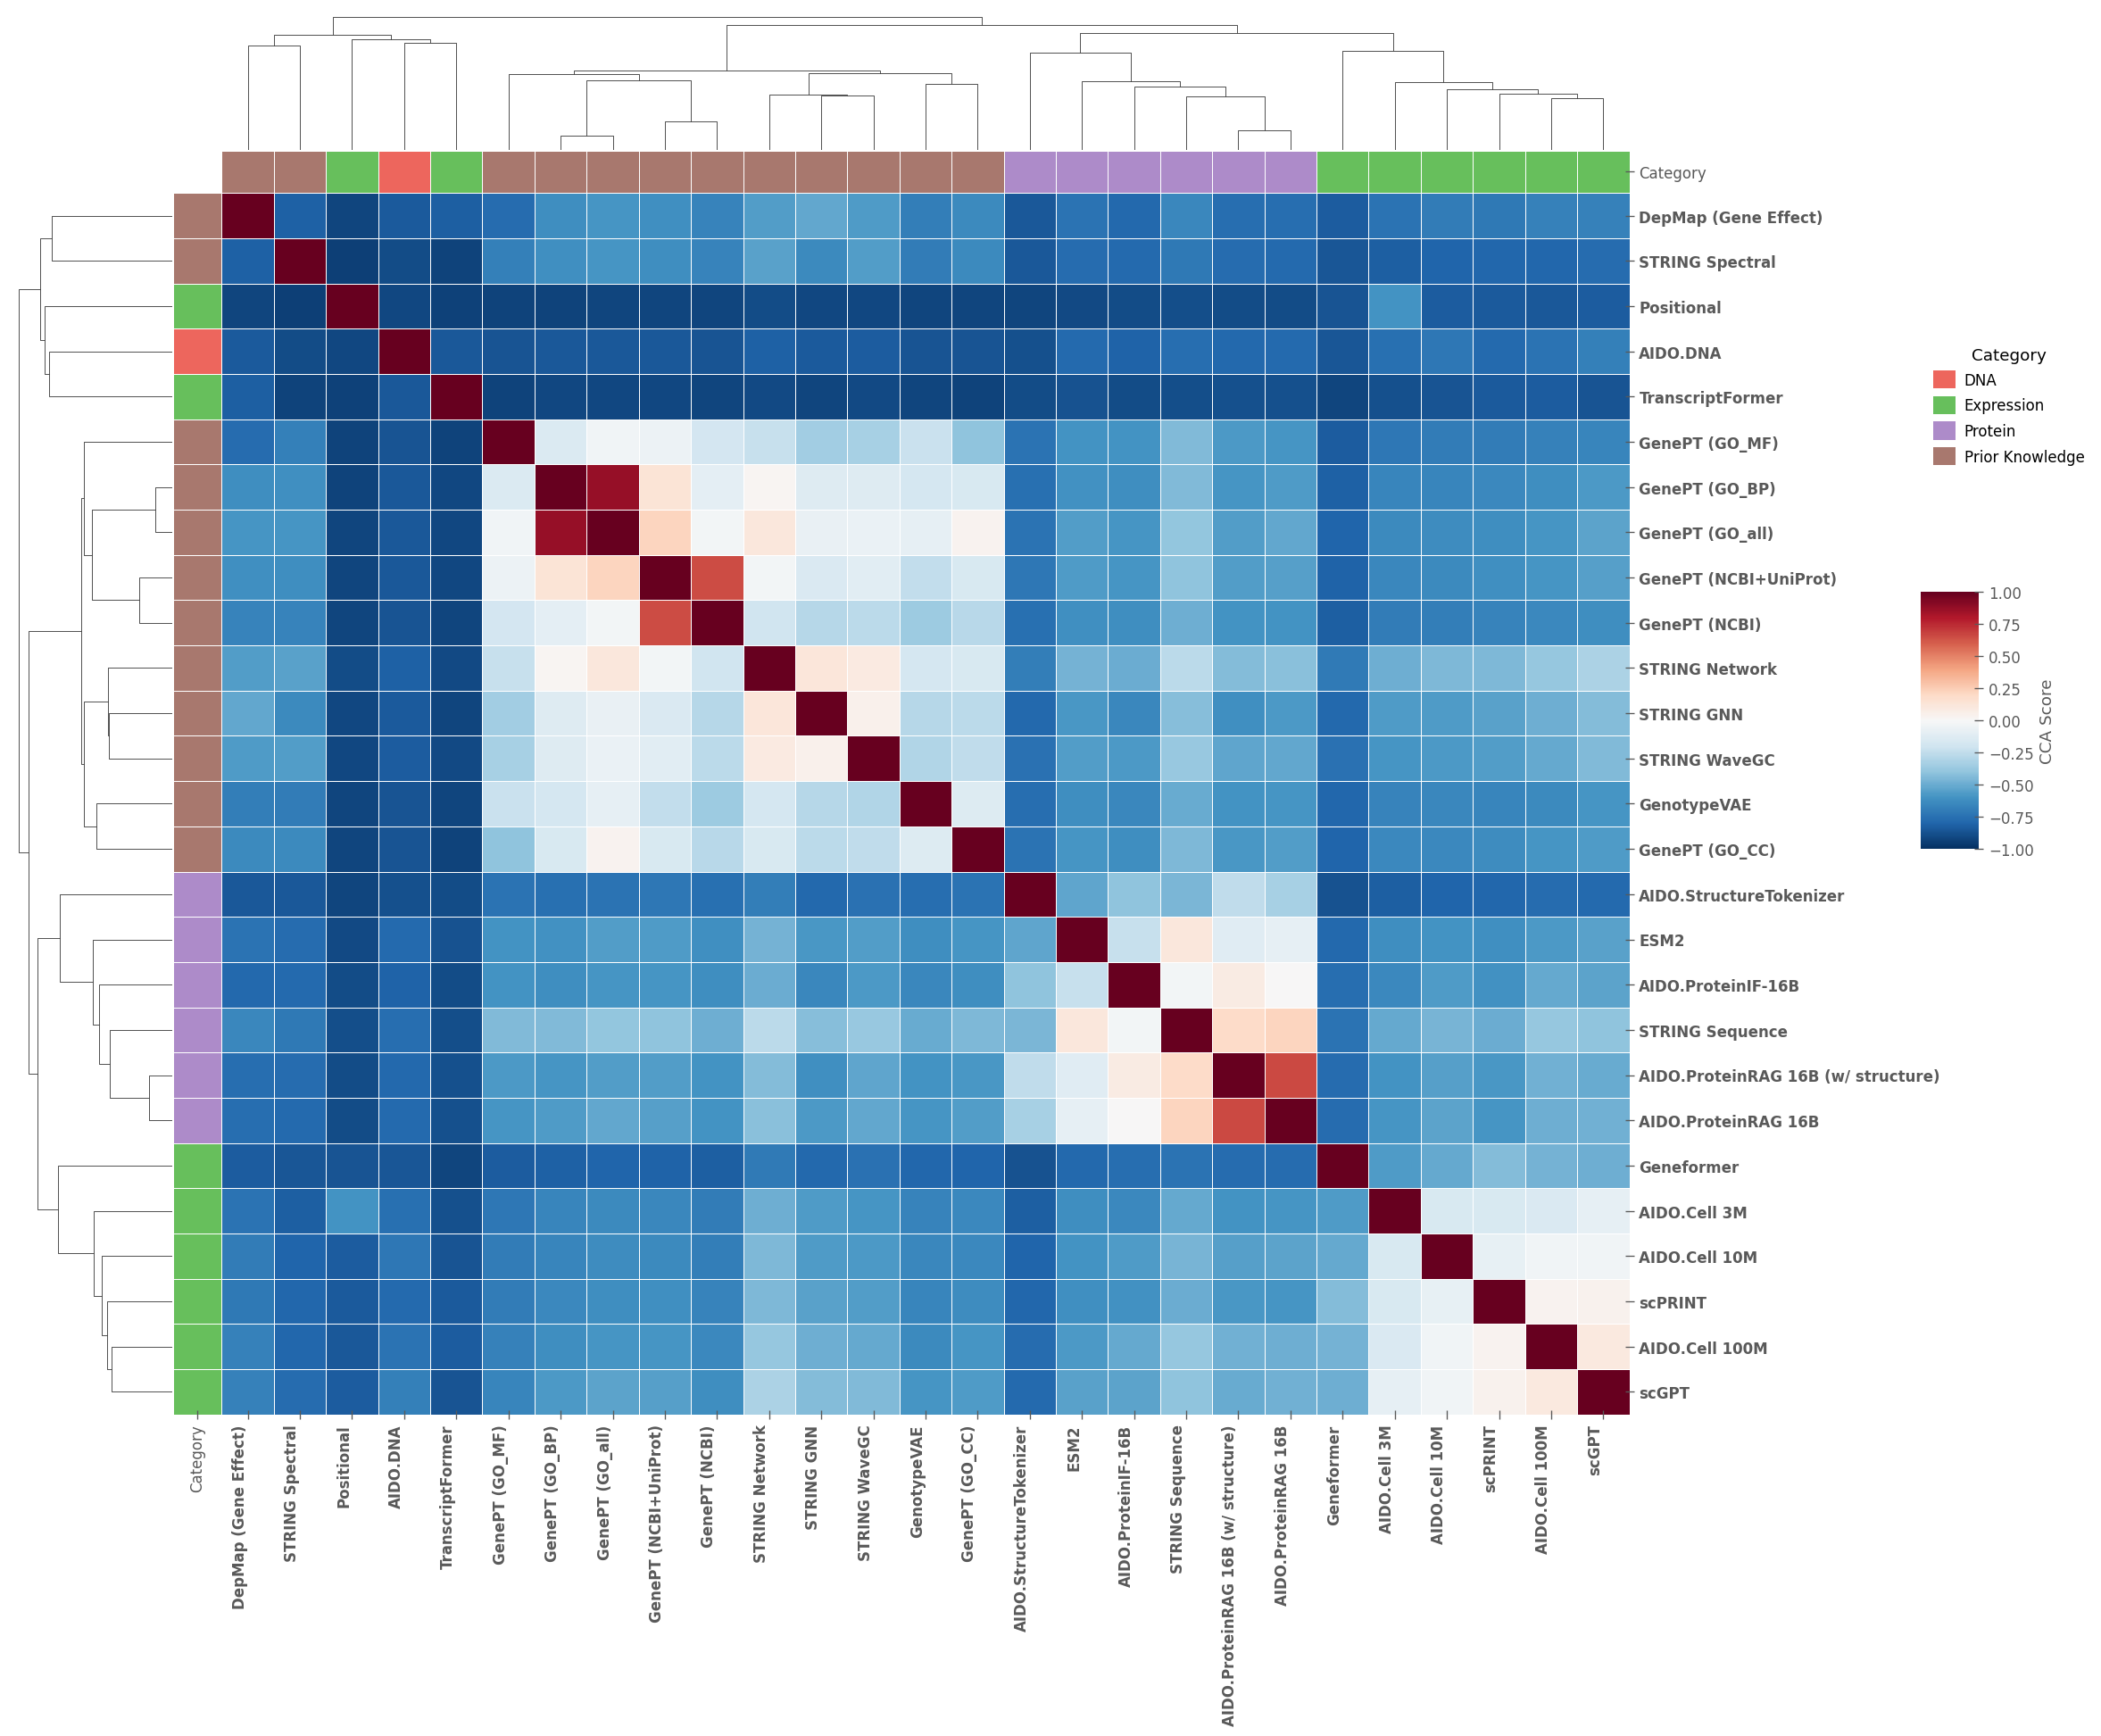

In [8]:
# Method mapping: raw name -> (pretty name, category)
METHOD_MAP = {
    # DNA
    "AIDOdna_(D=4352)": ("AIDO.DNA", "DNA"),
    
    # Protein
    "AIDOprot_mean_(D=384)": ("AIDO.StructureTokenizer", "Protein"),
    "AIDOprot_seq+struct_(D=1024)": ("AIDO.ProteinIF-16B", "Protein"),
    "ESM2_(D=1280)": ("ESM2", "Protein"),
    "RAG-16B_Human_Protein_Embedding_with_structure_mean_pooled_(D=2304)": ("AIDO.ProteinRAG 16B (w/ structure)", "Protein"),
    "RAG-16B_Human_Protein_Embedding_without_structure_mean_pooled_(D=2304)": ("AIDO.ProteinRAG 16B", "Protein"),
    "STRING_sequence_(D=1024)": ("STRING Sequence", "Protein"),
    
    # Expression
    "TranscriptFormer_essential_CELL_LINE_controls_(D=2048)": ("TranscriptFormer", "Expression"),
    "Geneformer_essential_CELL_LINE_controls_(D=512)": ("Geneformer", "Expression"),
    "AIDO.Cell_3M_positional_(D=128)": ("Positional", "Expression"),
    # "AIDO.Cell_10M_positional_(D=256)": ("Positional (10M)", "Expression"),
    # "AIDO.Cell_100M_positional_(D=640)": ("Positional (100M)", "Expression"),
    "AIDOcell_3M_essential_CELL_LINE_2025_11_26_(D=128)": ("AIDO.Cell 3M", "Expression"),
    "AIDOcell_10M_essential_CELL_LINE_2025_11_26_(D=256)": ("AIDO.Cell 10M", "Expression"),
    "AIDOcell_100M_essential_CELL_LINE_2025_11_26_(D=640)": ("AIDO.Cell 100M", "Expression"),
    "scGPT_essential_CELL_LINE_controls_(D=512)": ("scGPT", "Expression"),
    "scPRINT_essential_CELL_LINE_controls_(D=512)": ("scPRINT", "Expression"),
    
    # Prior Knowledge - Language
    "scGenePT_GO_BP_(D=1536)": ("GenePT (GO_BP)", "Prior Knowledge"),
    "scGenePT_GO_CC_(D=1536)": ("GenePT (GO_CC)", "Prior Knowledge"),
    "scGenePT_GO_MF_(D=1536)": ("GenePT (GO_MF)", "Prior Knowledge"),
    "scGenePT_GO_all_(D=1536)": ("GenePT (GO_all)", "Prior Knowledge"),
    "scGenePT_NCBI+UniProt_(D=1536)": ("GenePT (NCBI+UniProt)", "Prior Knowledge"),
    "scGenePT_NCBI_(D=1536)": ("GenePT (NCBI)", "Prior Knowledge"),
    
    # Prior Knowledge - Other
    "DepMap_Gene_Effect_(D=318)": ("DepMap (Gene Effect)", "Prior Knowledge"),
    "GenotypeVAE_(D=256)": ("GenotypeVAE", "Prior Knowledge"),
    
    # Prior Knowledge - Network
    "KG_WaveGC_G_StringDB_combined_0.0_(D=128)": ("STRING WaveGC", "Prior Knowledge"),
    "GNN_Simple_Official_(D=256)": ("STRING GNN", "Prior Knowledge"),
    "STRING_Spectral_Medium_Conf_(D=128)": ("STRING Spectral", "Prior Knowledge"),
    "STRING_network_(D=512)": ("STRING Network", "Prior Knowledge"),
}

# List of all embeddings to compare (derived from METHOD_MAP keys)
EMBEDDINGS = list(METHOD_MAP.keys())

# Model to category type mapping (derived from METHOD_MAP)
MODEL_TO_TYPE = {name: info[1] for name, info in METHOD_MAP.items()}

# Color palette for categories (avoiding red/blue due to heatmap colormap)
CATEGORY_COLORS = {
    "DNA": "#ED665DFF",
    "Expression": "#67BF5CFF",
    "Protein": "#AD8BC9FF",
    "Prior Knowledge": "#A8786EFF",
}

CELL_LINE = "K-562"


def create_short_names(original_names):
    """Convert raw embedding names to pretty display names using METHOD_MAP."""
    return [METHOD_MAP.get(name, (name,))[0] for name in original_names]


def plot_heatmap(sim_df, output_path="embedding_similarity_heatmap.pdf"):
    """Create and save CCA similarity heatmap with category colors."""
    # Create shorter names for display
    original_names = sim_df.index.tolist()
    short_names = create_short_names(original_names)
    sim_df_display = sim_df.copy()
    sim_df_display.index = short_names
    sim_df_display.columns = short_names

    # Create category color mapping for rows/columns
    categories = [MODEL_TO_TYPE.get(name, "Unknown") for name in original_names]
    row_colors = pd.Series(
        [CATEGORY_COLORS.get(cat, "#999999") for cat in categories],
        index=short_names,
        name="Category"
    )

    # Create clustermap with category colors
    g = sns.clustermap(
        sim_df_display,
        annot=False,
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        linecolor="white",
        cbar_pos=(1, 0.5, 0.03, 0.15),  # (left, bottom, width, height)
        cbar_kws={"label": "CCA Score"},
        figsize=(18, 16),
        dendrogram_ratio=(0.1, 0.1),
        row_colors=row_colors,
        col_colors=row_colors,
    )

    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, ha="right", fontsize=10, fontweight="bold")
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=10, fontweight="bold")

    # Add legend for categories
    legend_handles = [Patch(facecolor=color, label=cat) for cat, color in CATEGORY_COLORS.items()]
    g.fig.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1, 0.8),
        title="Category",
        frameon=True,
    )

    plt.savefig(output_path, format="pdf", bbox_inches="tight", dpi=300)
    print(f"\nSaved heatmap to {output_path}")
    plt.show()


# 6. Plot heatmap
print("\nPlotting heatmap...")
output_path = "fig_3.pdf"
plot_heatmap(sim_df, output_path)